# Chapter 7: Subsea Production Systems

This notebook demonstrates subsea production system analysis using NeqSim:
- Pressure profile along a subsea pipeline
- Temperature profile and cooling effects
- Hydrate formation risk assessment (equilibrium temperature overlay)
- Flow regime map for multiphase subsea flow
- System pressure budget from reservoir to topsides

Subsea pipelines transport multiphase fluids over long distances in cold seawater
environments, making flow assurance a critical design consideration.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch06_subsea_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# NeqSim class imports
Stream = jneqsim.process.equipment.stream.Stream
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 7)})


## Create Wet Gas Fluid

We define a wet gas fluid typical of a subsea gas-condensate field with water.

In [3]:
def create_subsea_fluid():
    """Create a wet gas fluid for subsea pipeline modeling."""
    T_K = 273.15 + 70.0  # Wellhead temperature
    P_bara = 150.0  # Wellhead pressure

    fluid = SystemSrkEos(T_K, P_bara)
    fluid.addComponent("nitrogen", 0.8)
    fluid.addComponent("CO2", 2.5)
    fluid.addComponent("methane", 75.0)
    fluid.addComponent("ethane", 7.0)
    fluid.addComponent("propane", 4.0)
    fluid.addComponent("i-butane", 1.0)
    fluid.addComponent("n-butane", 1.5)
    fluid.addComponent("i-pentane", 0.5)
    fluid.addComponent("n-pentane", 0.5)
    fluid.addComponent("n-hexane", 1.0)
    fluid.addComponent("n-heptane", 1.2)
    fluid.addComponent("water", 5.0)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid

fluid = create_subsea_fluid()
ops = ThermodynamicOperations(fluid)
ops.TPflash()
fluid.initProperties()
assert _physics.state(fluid, 'calculation_cell_4:fluid', candidate=False)
print(f"Phases: {fluid.getNumberOfPhases()}")
print(f"Gas density: {fluid.getPhase('gas').getDensity('kg/m3'):.2f} kg/m3")


Phases: 2
Gas density: 147.82 kg/m3


## Figures 1 & 2: Pressure and Temperature Profiles Along Subsea Pipeline

We simulate a subsea flowline as multiple pipe segments to capture the pressure and
temperature profiles along the pipeline length. The pipeline transfers multiphase fluid
from the subsea wellhead to the platform riser base.

In [4]:
# Pipeline parameters
total_length = 20000.0  # 20 km flowline
n_segments = 10
seg_length = total_length / n_segments
pipe_diameter = 0.254  # 10 inch ID
roughness = 5.0e-5  # m
elevation_per_seg = 0.0  # Horizontal (seabed)

# Inlet conditions
T_inlet_K = 273.15 + 70.0
P_inlet_bara = 150.0
mass_rate = 50000.0  # kg/hr

# Track profiles
distances = [0.0]
pressures = [P_inlet_bara]
temperatures = [70.0]  # °C

# Current stream conditions
current_T = T_inlet_K
current_P = P_inlet_bara

for seg in range(n_segments):
    fluid_seg = create_subsea_fluid()
    feed = Stream(f"seg_{seg}", fluid_seg)
    feed.setFlowRate(mass_rate, "kg/hr")
    feed.setTemperature(current_T, "K")
    feed.setPressure(current_P, "bara")

    pipe = PipeBeggsAndBrills(f"pipe_{seg}", feed)
    pipe.setPipeWallRoughness(roughness)
    pipe.setLength(seg_length)
    pipe.setElevation(elevation_per_seg)
    pipe.setDiameter(pipe_diameter)

    process = ProcessSystem()
    process.add(feed)
    process.add(pipe)

    try:
        process.run()
        assert _physics.run(process, 'calculation_cell_6:process', candidate=True)
        current_P = pipe.getOutletStream().getPressure("bara")
        current_T = pipe.getOutletStream().getTemperature("K")

        distances.append((seg + 1) * seg_length / 1000.0)  # km
        pressures.append(current_P)
        temperatures.append(current_T - 273.15)  # °C
    except Exception as e:
        print(f"Segment {seg} failed: {e}")
        break

print(f"Inlet: P={P_inlet_bara:.1f} bara, T={T_inlet_K-273.15:.1f} °C")
print(f"Outlet: P={pressures[-1]:.1f} bara, T={temperatures[-1]:.1f} °C")
print(f"Total dP = {P_inlet_bara - pressures[-1]:.1f} bar")


Inlet: P=150.0 bara, T=70.0 °C
Outlet: P=146.5 bara, T=70.0 °C
Total dP = 3.5 bar


Figure 1 saved.


ch06_subsea_figures.ipynb:cell7:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


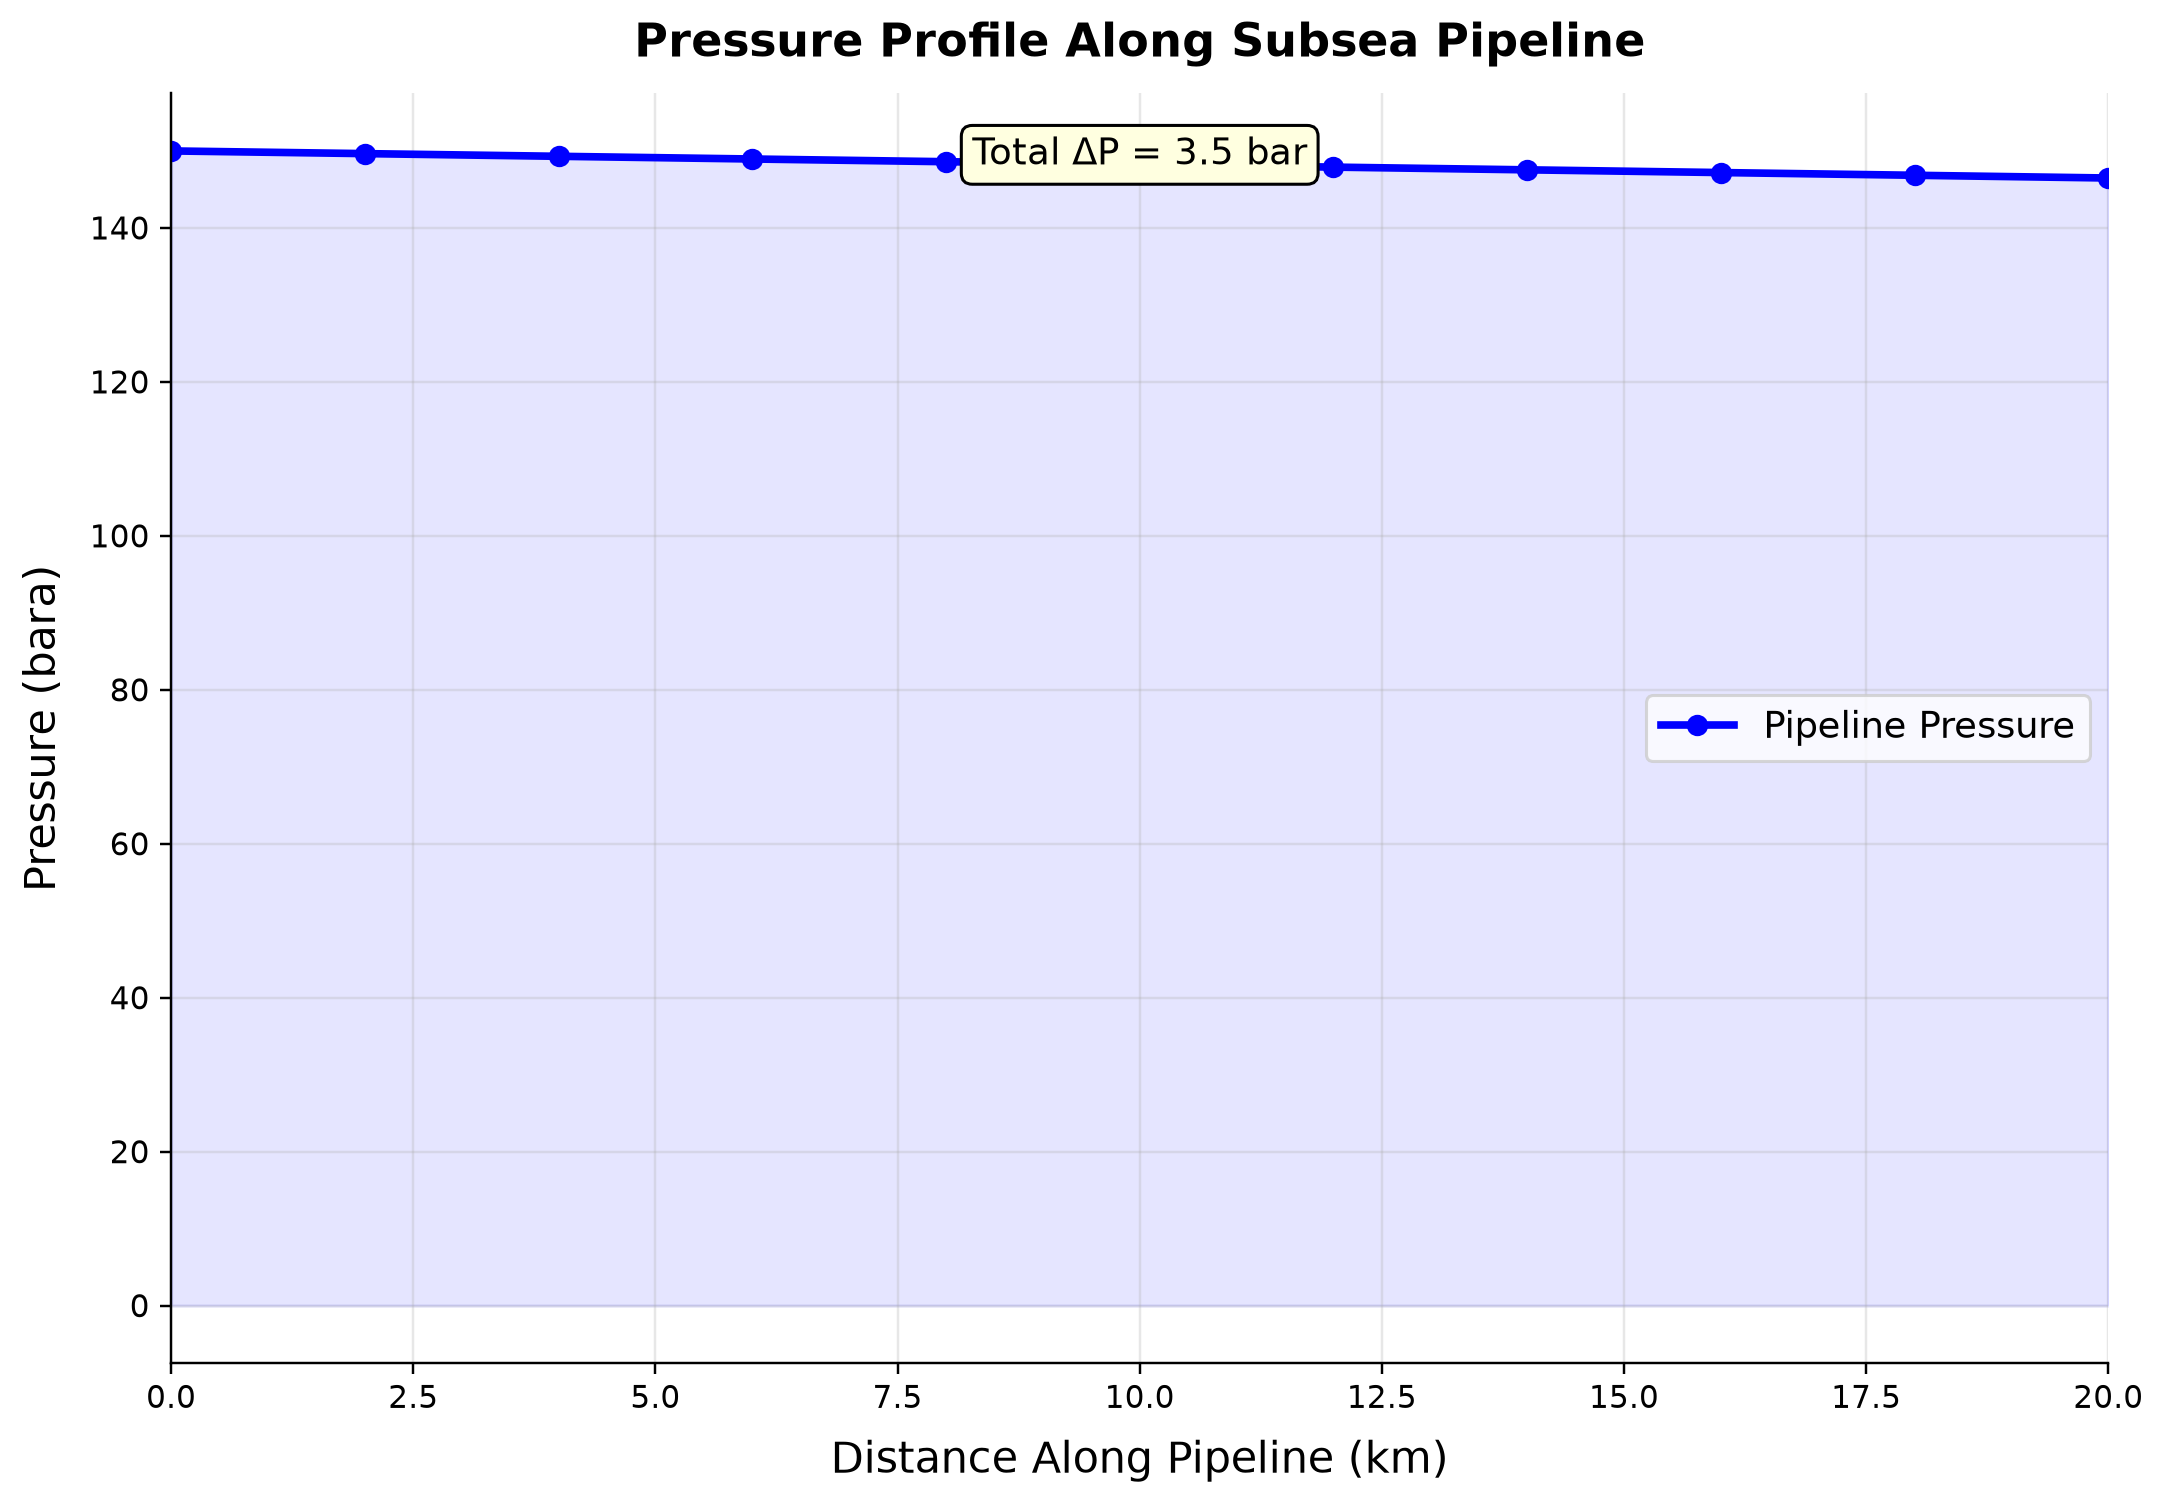

In [5]:
# Figure 1: Pressure profile
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(distances, pressures, 'b-o', linewidth=2.5, markersize=6, label='Pipeline Pressure')
ax.fill_between(distances, pressures, alpha=0.1, color='blue')

ax.set_xlabel('Distance Along Pipeline (km)', fontsize=14)
ax.set_ylabel('Pressure (bara)', fontsize=14)
ax.set_title('Pressure Profile Along Subsea Pipeline', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, total_length / 1000.0)

# Annotate pressure drop
dp_total = P_inlet_bara - pressures[-1]
ax.annotate(f'Total ΔP = {dp_total:.1f} bar', xy=(distances[-1]/2, np.mean(pressures)),
            fontsize=12, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch06_fig01_pressure_profile.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


**Executed-figure discussion.** Pipeline Pressure: pressure spans 146.5–150 bara across the plotted cases.

Friction and elevation redistribute pressure along the subsea route; changing density and phase holdup alters the local gradient. The arrival pressure determines how much pressure is available for the riser and receiving plant, rather than constituting a free design input. Use the surveyed elevation profile, verify the pressure budget and refine segmentation until the arrival pressure is stable.


Figure 2 saved.


ch06_subsea_figures.ipynb:cell8:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


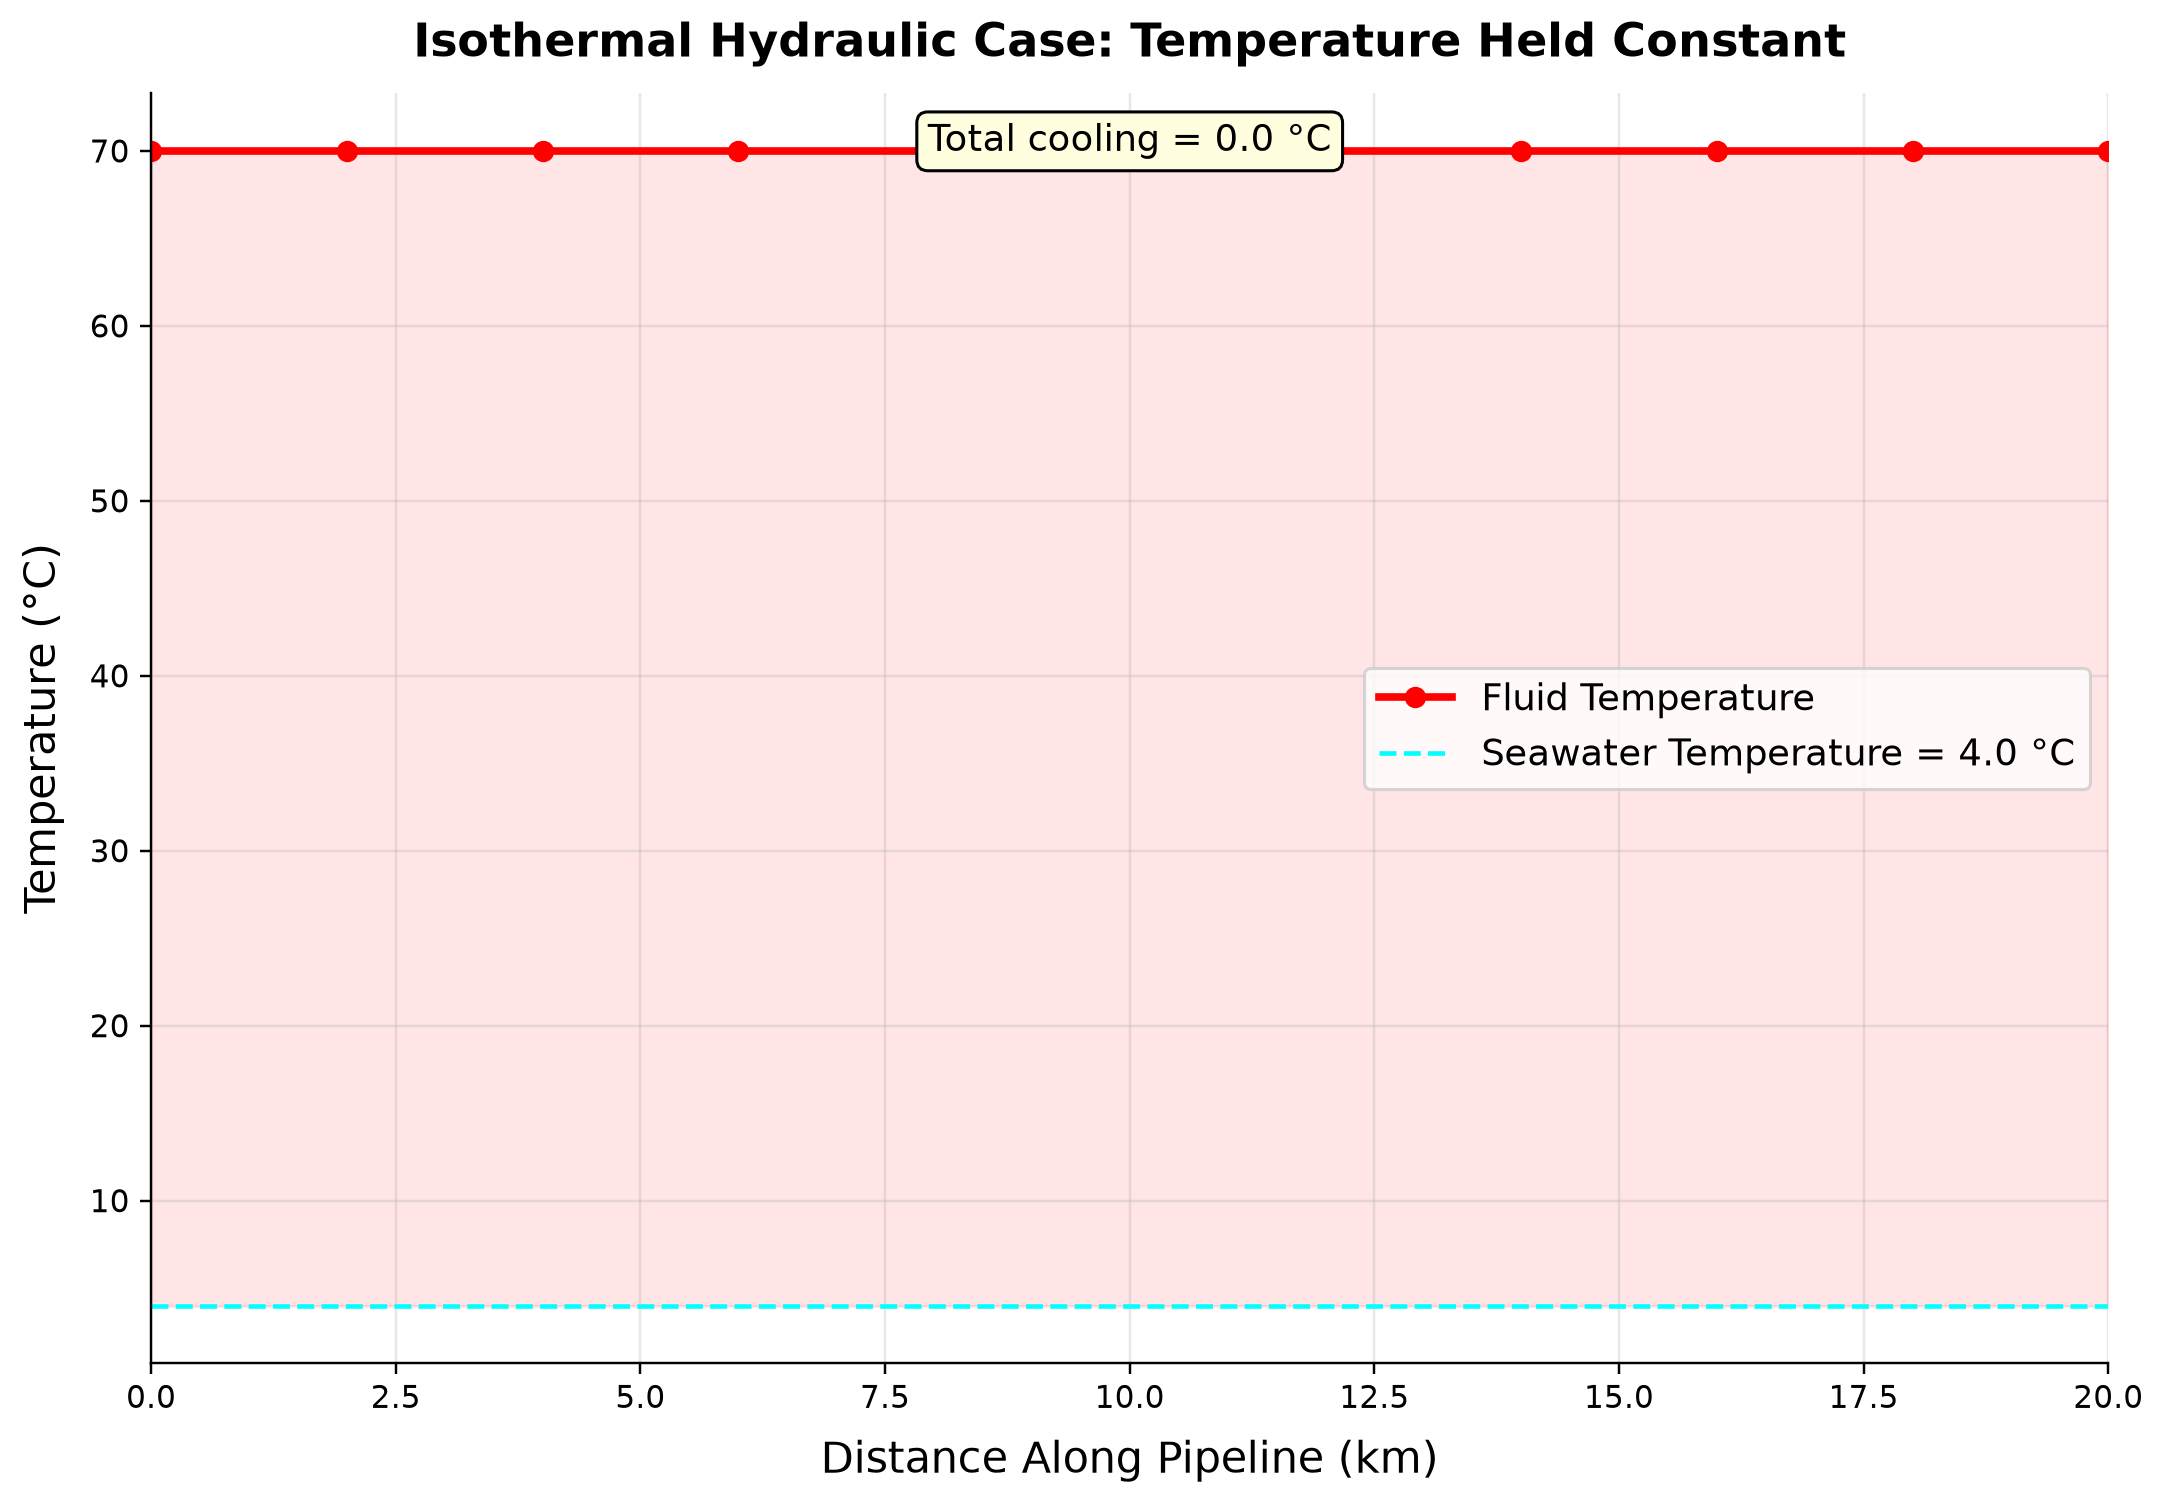

In [6]:
# Figure 2: Temperature profile
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(distances, temperatures, 'r-o', linewidth=2.5, markersize=6, label='Fluid Temperature')

# Seawater temperature reference
T_seawater = 4.0  # °C at seabed
ax.axhline(y=T_seawater, color='cyan', linestyle='--', linewidth=1.5,
           label=f'Seawater Temperature = {T_seawater} °C')
ax.fill_between(distances, T_seawater, temperatures, alpha=0.1, color='red')

ax.set_xlabel('Distance Along Pipeline (km)', fontsize=14)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.set_title('Isothermal Hydraulic Case: Temperature Held Constant', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, total_length / 1000.0)

# Annotate cooling
dT_total = temperatures[0] - temperatures[-1]
ax.annotate(f'Total cooling = {dT_total:.1f} °C', xy=(distances[-1]/2, np.mean(temperatures)),
            fontsize=12, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch06_fig02_temperature_profile.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")


**Executed-figure discussion.** Fluid Temperature: temperature remains 70 °C across the plotted cases.

This notebook holds each pipeline segment at the specified 70 degree Celsius temperature; heat transfer to the seabed is not solved. The flat profile is an isothermal boundary assumption and cannot quantify normal-operation cooling or shutdown margin. Enable and calibrate a thermal model before using arrival temperature to select insulation or hydrate protection.


## Figure 3: Hydrate Formation Risk - T-P Overlay

Gas hydrates form when water and light hydrocarbons are present at high pressure and low
temperature. We compute the hydrate equilibrium curve using NeqSim and overlay the
pipeline operating conditions to identify risk zones.

Figure 3 saved.


ch06_subsea_figures.ipynb:cell10:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


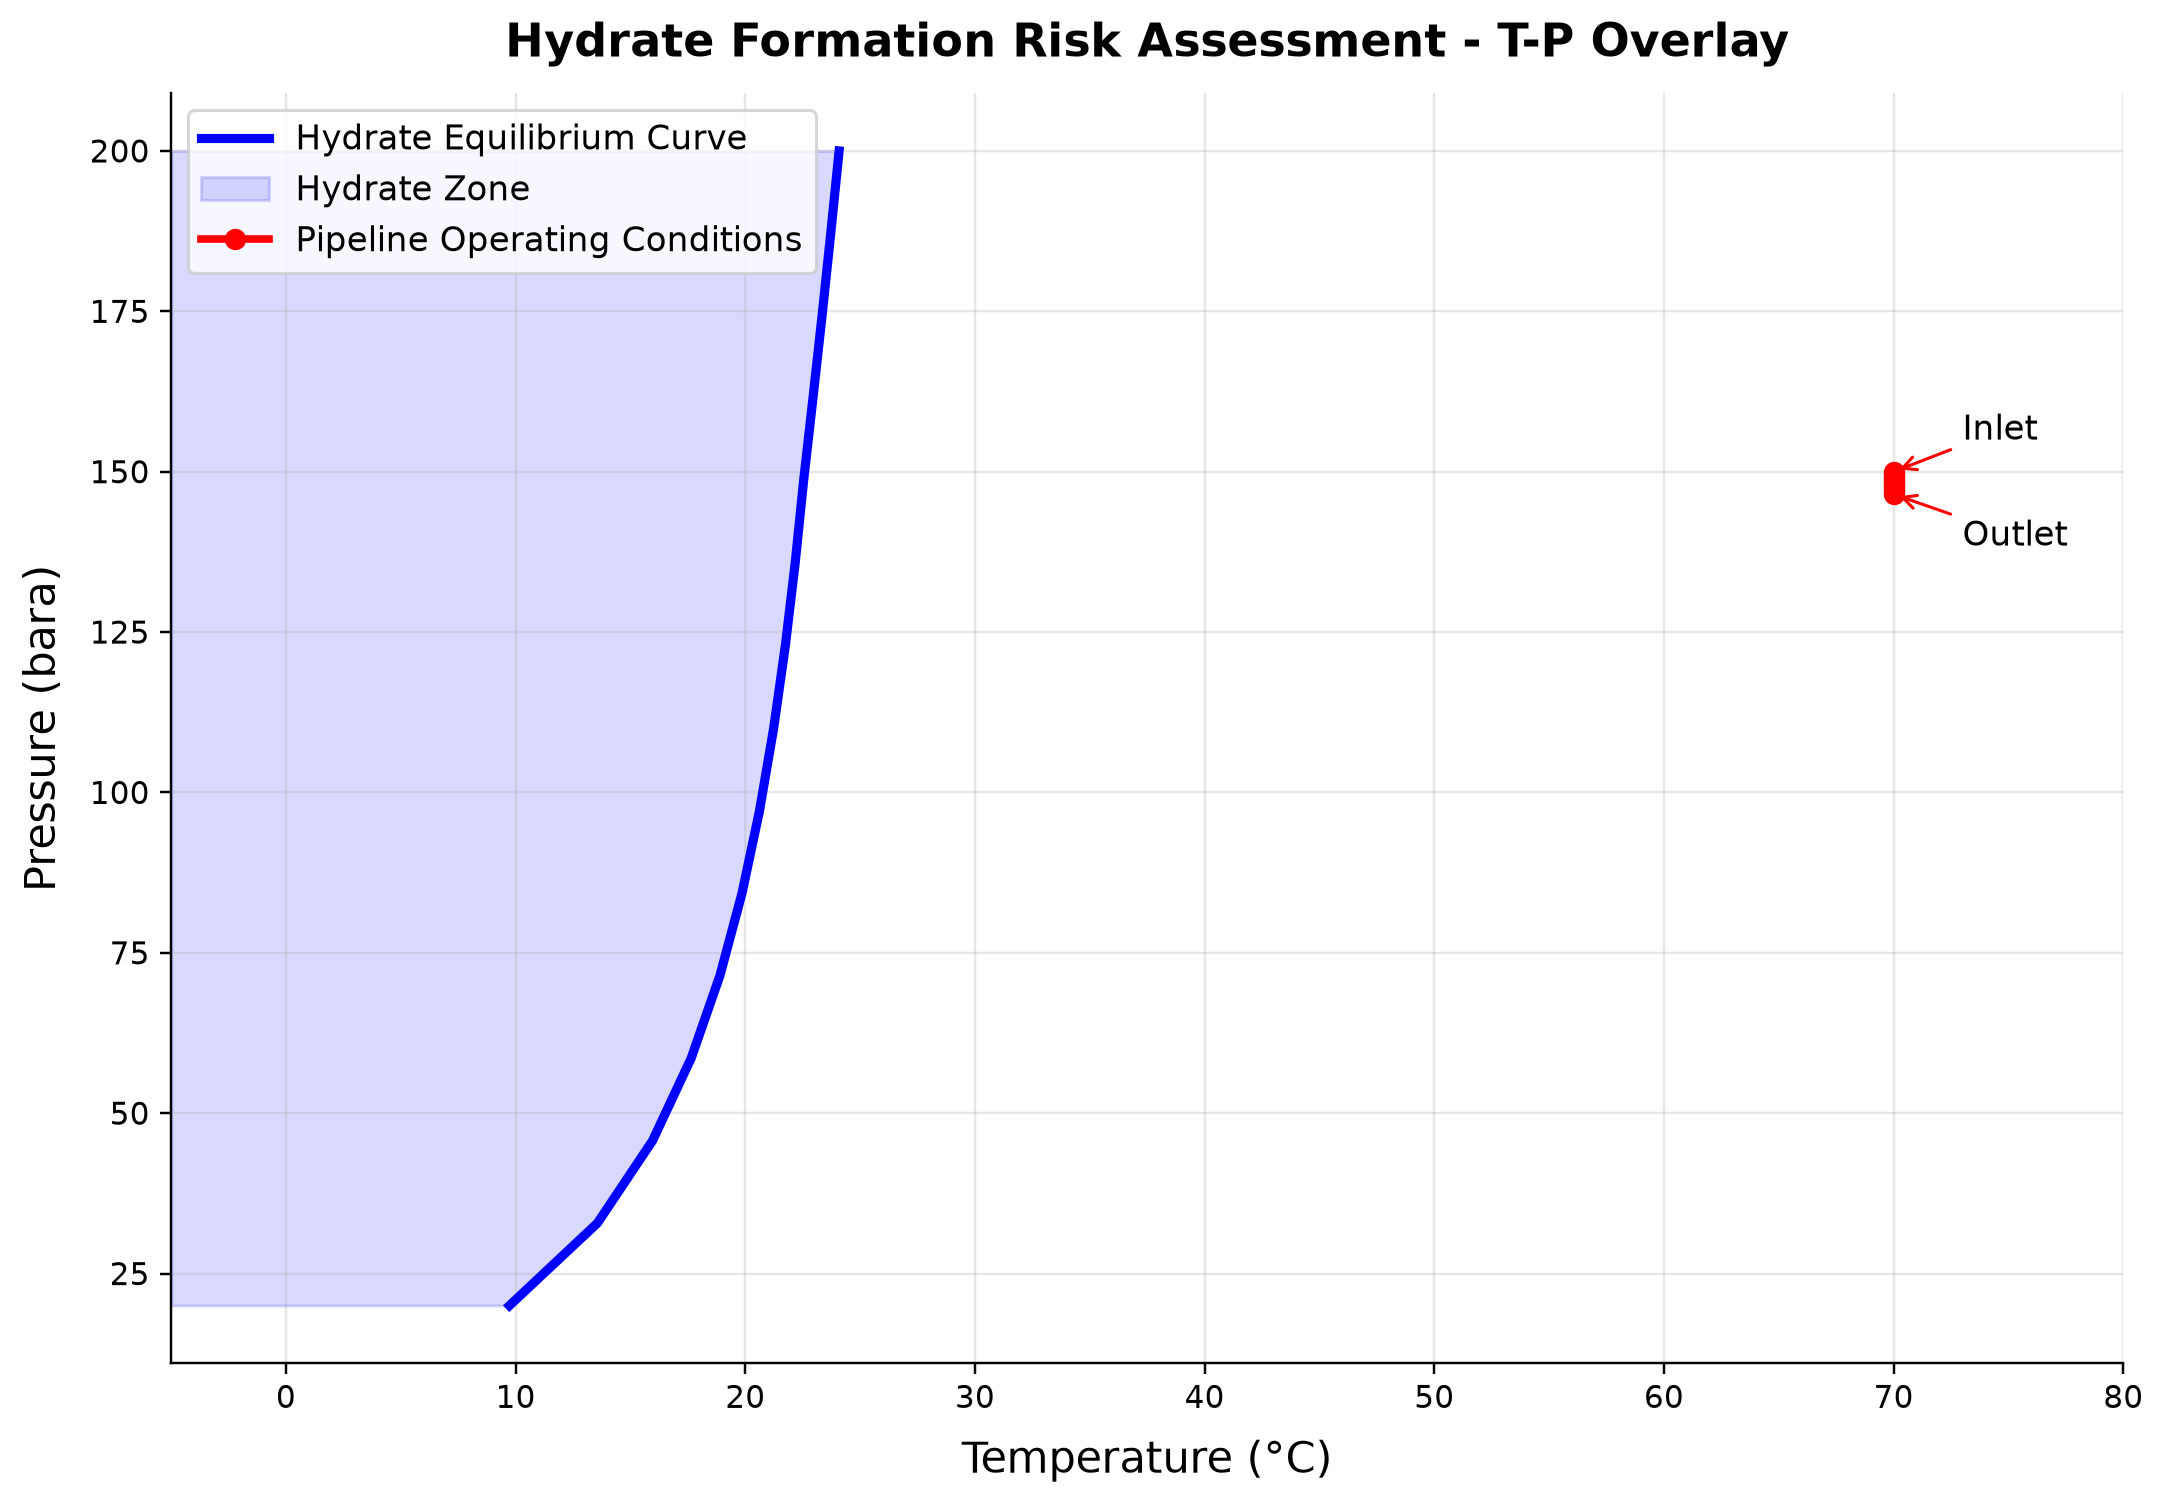

In [7]:
# Calculate hydrate equilibrium temperature at various pressures
hydrate_pressures = np.linspace(20, 200, 15)
hydrate_temps = []

for p in hydrate_pressures:
    try:
        h_fluid = create_subsea_fluid()
        h_fluid.setPressure(float(p))
        h_fluid.setTemperature(273.15 + 5.0)  # Initial guess
        h_fluid.setHydrateCheck(True)
        h_ops = ThermodynamicOperations(h_fluid)
        h_ops.hydrateFormationTemperature()
        h_T = h_fluid.getTemperature("C")
        hydrate_temps.append(h_T)
    except Exception as error:
        raise RuntimeError(f"Hydrate equilibrium failed at {p:.1f} bara: {error}")

assert np.all(np.isfinite(hydrate_temps)), "Hydrate curve must be finite"
fig, ax = plt.subplots(figsize=(10, 7))

# Hydrate equilibrium curve
valid_mask = [not np.isnan(t) for t in hydrate_temps]
h_p_valid = [p for p, v in zip(hydrate_pressures, valid_mask) if v]
h_t_valid = [t for t, v in zip(hydrate_temps, valid_mask) if v]

if h_t_valid:
    ax.plot(h_t_valid, h_p_valid, 'b-', linewidth=3, label='Hydrate Equilibrium Curve')
    ax.fill_betweenx(h_p_valid, -5, h_t_valid, alpha=0.15, color='blue', label='Hydrate Zone')

# Pipeline operating conditions (T,P from profiles)
ax.plot(temperatures, pressures, 'r-o', linewidth=2.5, markersize=6,
        label='Pipeline Operating Conditions')

# Mark inlet and outlet
ax.annotate('Inlet', xy=(temperatures[0], pressures[0]), fontsize=11,
            xytext=(temperatures[0]+3, pressures[0]+5),
            arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate('Outlet', xy=(temperatures[-1], pressures[-1]), fontsize=11,
            xytext=(temperatures[-1]+3, pressures[-1]-8),
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Temperature (°C)', fontsize=14)
ax.set_ylabel('Pressure (bara)', fontsize=14)
ax.set_title('Hydrate Formation Risk Assessment - T-P Overlay', fontsize=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 80)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch06_fig03_hydrate_risk.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


**Executed-figure discussion.** Hydrate Equilibrium Curve: pressure spans 20–200 bara across the plotted cases. Pipeline Operating Conditions: pressure spans 146.5–150 bara across the plotted cases.

The hydrate curve is a separate NeqSim equilibrium calculation; the operating points use the isothermal pipeline assumption. The 70 degree Celsius path is comfortably warmer than equilibrium in this constructed example, but its apparent margin does not account for actual seabed heat loss. Recompute the operating path with heat transfer and evaluate cooldown and free-water availability before selecting protection.


## Figure 4: Flow Regime Map (Conceptual)

Multiphase flow in pipelines exhibits different flow regimes depending on the superficial
velocities of gas and liquid phases. This conceptual map shows the typical regime boundaries
for horizontal flow.

Figure 4 saved.


ch06_subsea_figures.ipynb:cell12:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


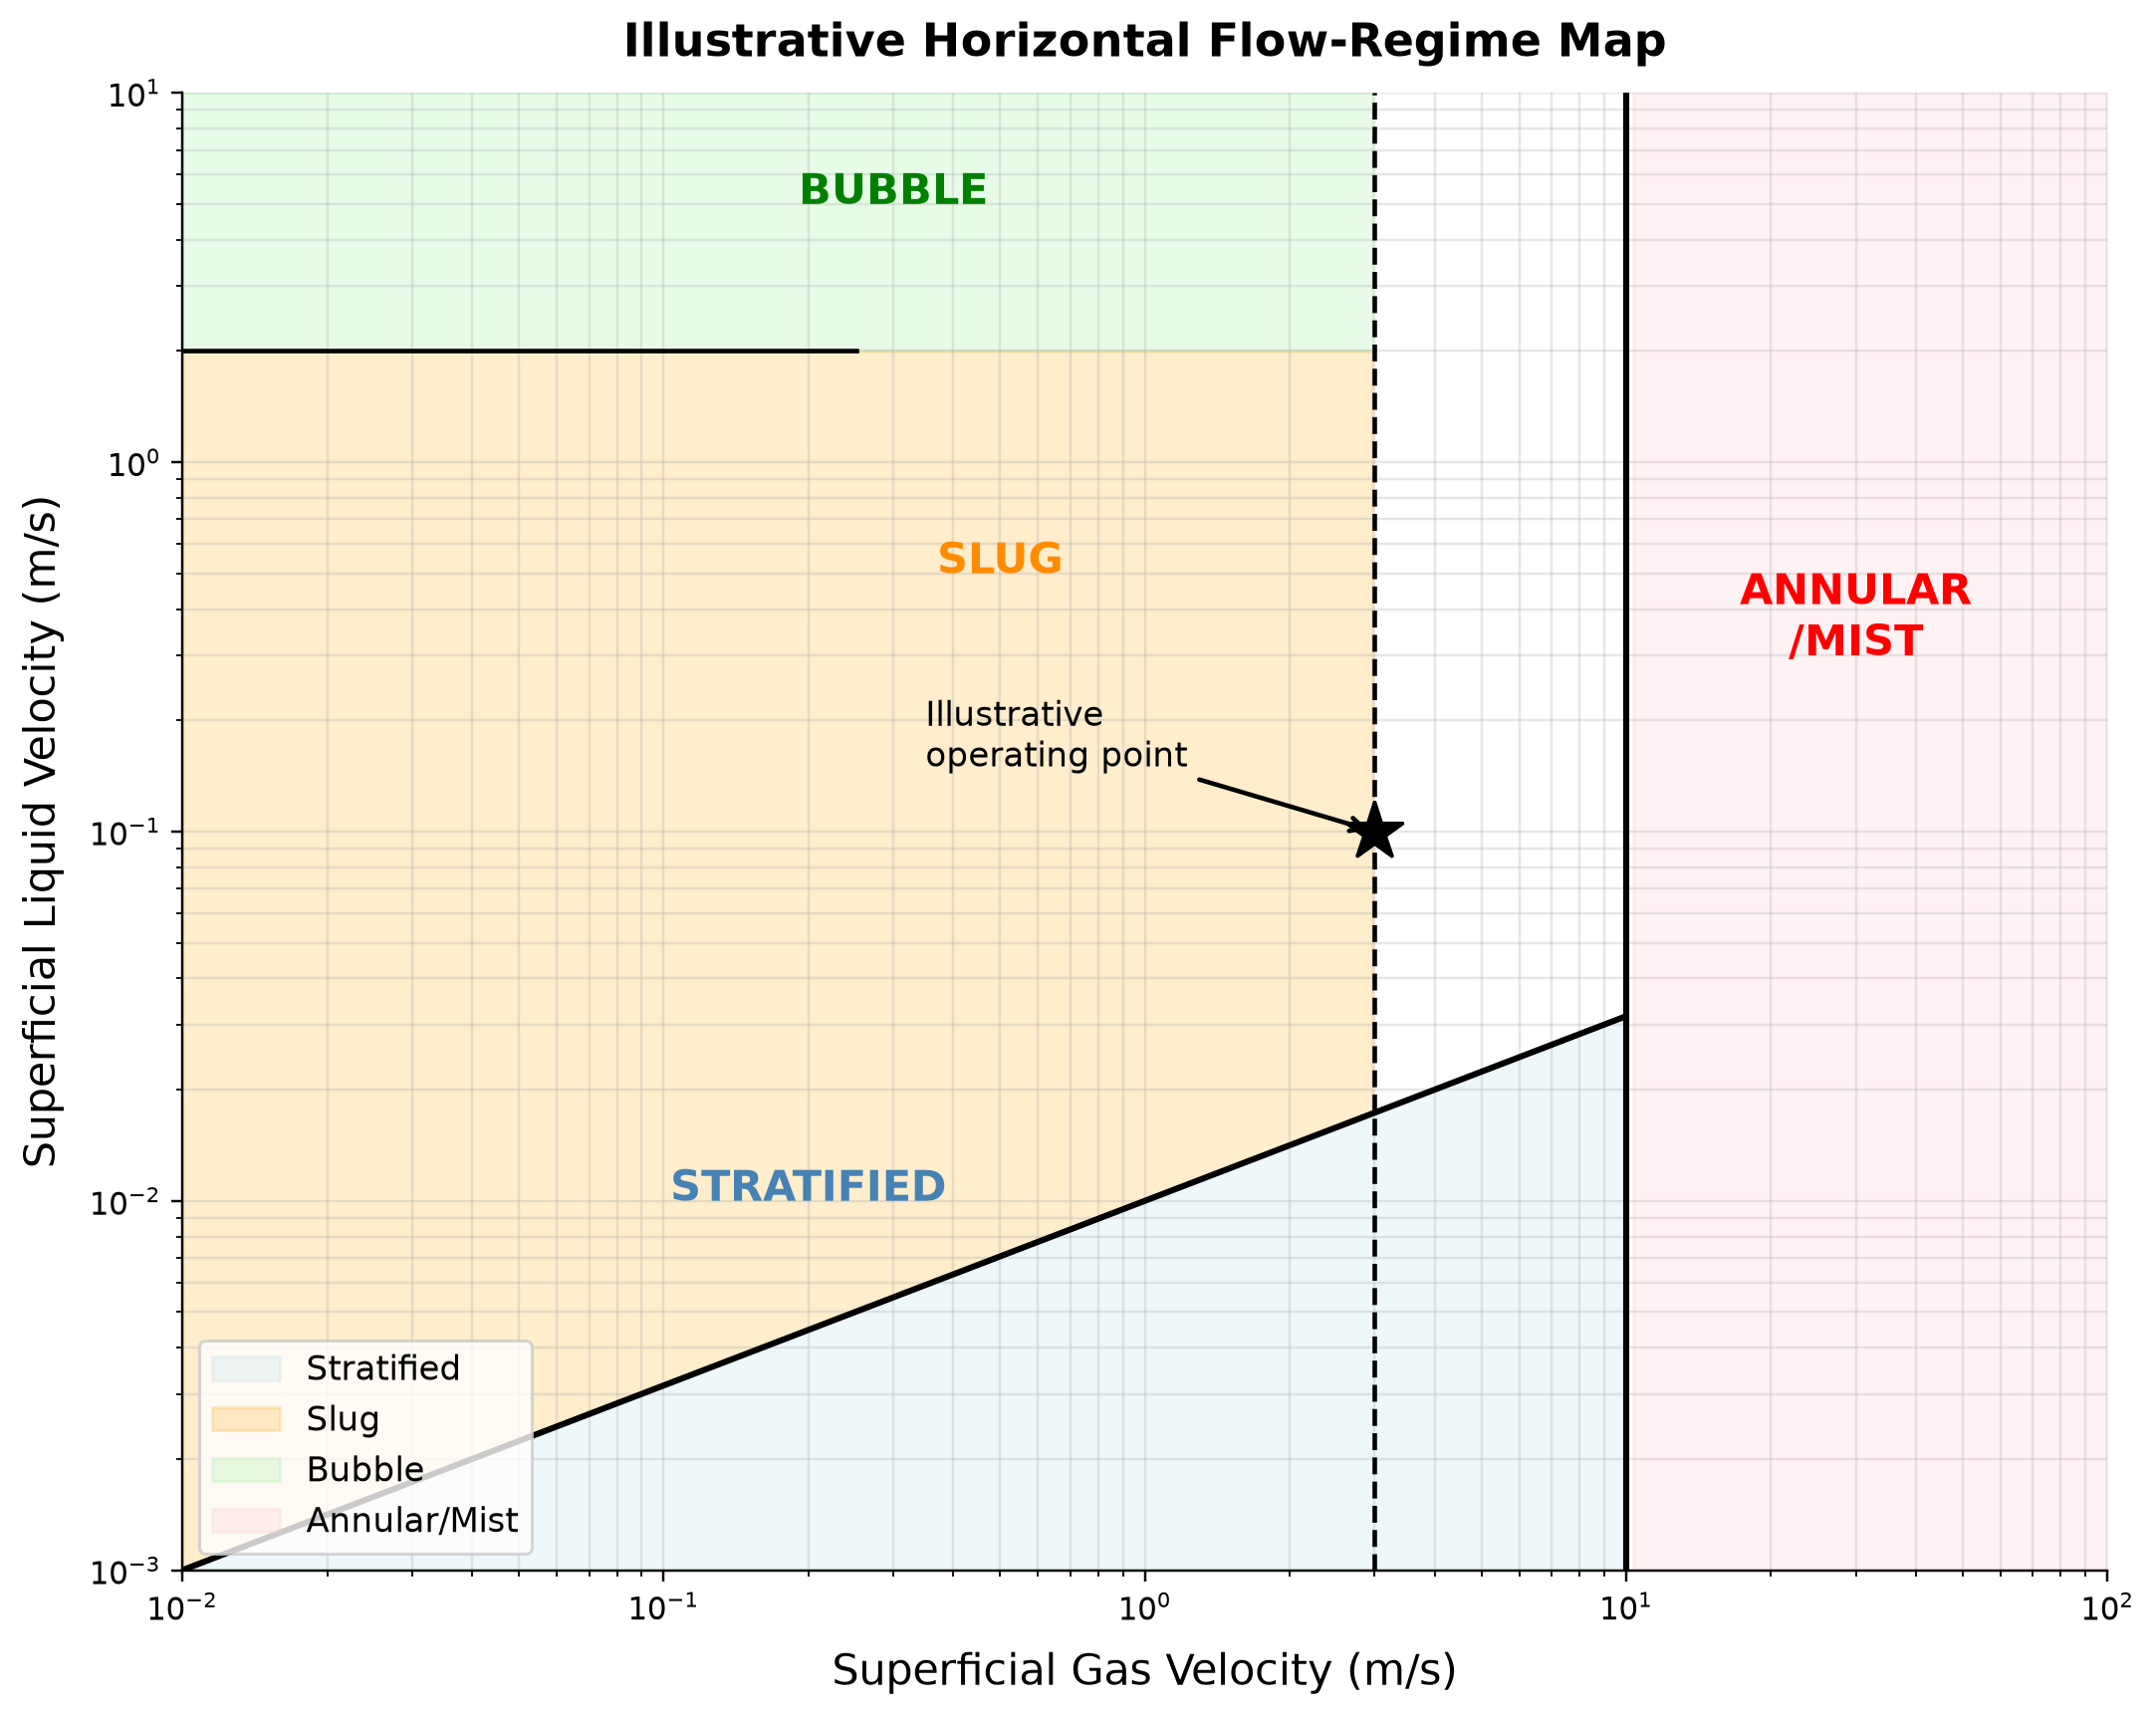

In [8]:
# Conceptual flow regime map for horizontal pipe
# Based on Taitel-Dukler / Baker chart concepts

fig, ax = plt.subplots(figsize=(10, 8))

# Regime boundary curves (conceptual)
vsg = np.logspace(-2, 2, 200)  # Superficial gas velocity (m/s)

# Stratified to slug boundary
vsl_strat_slug = 0.01 * vsg**0.5
# Slug to annular boundary
vsl_slug_annular = 5.0 / vsg**0.8
# Stratified to annular boundary (high gas)
vsl_strat_annular = 0.001 * np.ones_like(vsg)
# Bubble to slug boundary
vsl_bubble_slug = 2.0 * np.ones_like(vsg)

# Fill regime regions with colors
ax.fill_between(vsg, 0.001, np.minimum(vsl_strat_slug, 10),
                where=(vsg < 10), alpha=0.2, color='lightblue', label='Stratified')
ax.fill_between(vsg, vsl_strat_slug, np.minimum(vsl_bubble_slug, 10),
                where=(vsg < 3), alpha=0.2, color='orange', label='Slug')
ax.fill_between(vsg, vsl_bubble_slug, 10,
                where=(vsg < 3), alpha=0.2, color='lightgreen', label='Bubble')
ax.fill_between(vsg, 0.001, 10,
                where=(vsg > 10), alpha=0.2, color='pink', label='Annular/Mist')

# Plot boundaries
ax.loglog(vsg[vsg < 10], np.clip(vsl_strat_slug[vsg < 10], 0.001, 10),
          'k-', linewidth=2)
ax.loglog([3, 3], [0.001, 10], 'k--', linewidth=1.5)
ax.loglog([10, 10], [0.001, 10], 'k-', linewidth=2)
ax.axhline(y=2.0, xmin=0, xmax=0.35, color='k', linewidth=1.5, linestyle='-')

# Regime labels
ax.text(0.2, 0.01, 'STRATIFIED', fontsize=14, fontweight='bold', color='steelblue', ha='center')
ax.text(0.5, 0.5, 'SLUG', fontsize=14, fontweight='bold', color='darkorange', ha='center')
ax.text(0.3, 5, 'BUBBLE', fontsize=14, fontweight='bold', color='green', ha='center')
ax.text(30, 0.3, 'ANNULAR\n/MIST', fontsize=14, fontweight='bold', color='red', ha='center')

# Example operating point
ax.plot(3.0, 0.1, 'k*', markersize=20, zorder=5)
ax.annotate('Illustrative\noperating point', xy=(3.0, 0.1),
            xytext=(0.35, 0.15), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlabel('Superficial Gas Velocity (m/s)', fontsize=14)
ax.set_ylabel('Superficial Liquid Velocity (m/s)', fontsize=14)
ax.set_title('Illustrative Horizontal Flow-Regime Map', fontsize=15)
ax.set_xlim(0.01, 100)
ax.set_ylim(0.001, 10)
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11, loc='lower left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch06_fig04_flow_regime_map.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


**Executed-figure discussion.** Superficial Liquid Velocity spans 0.001–0.03144 m/s across the plotted cases.

Superficial gas and liquid velocities characterize the competing inertia, buoyancy and phase-continuity mechanisms that form flow regimes. A horizontal regime map is a screening tool and may not describe inclined sections, risers or transient severe slugging. Use regime labels within the correlation’s domain and assess liquid accumulation and transient slugging for the actual route.


## Figure 5: Subsea System Pressure Budget

The total pressure available from the reservoir must overcome all pressure losses
in the production system. A pressure budget helps identify the limiting components
and opportunities for optimization.


Pressure Budget Summary:
  Reservoir pressure:    300 bara
  Reservoir Drawdown       : -50 bar
  Wellbore Lift            : -30 bar
  Xmas Tree                : -5 bar
  Flowline Friction        : -4 bar
  Riser                    : -25 bar
  Topsides Equipment       : -10 bar
  Arrival pressure         : 176 bara
Figure 5 saved.


ch06_subsea_figures.ipynb:cell14:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


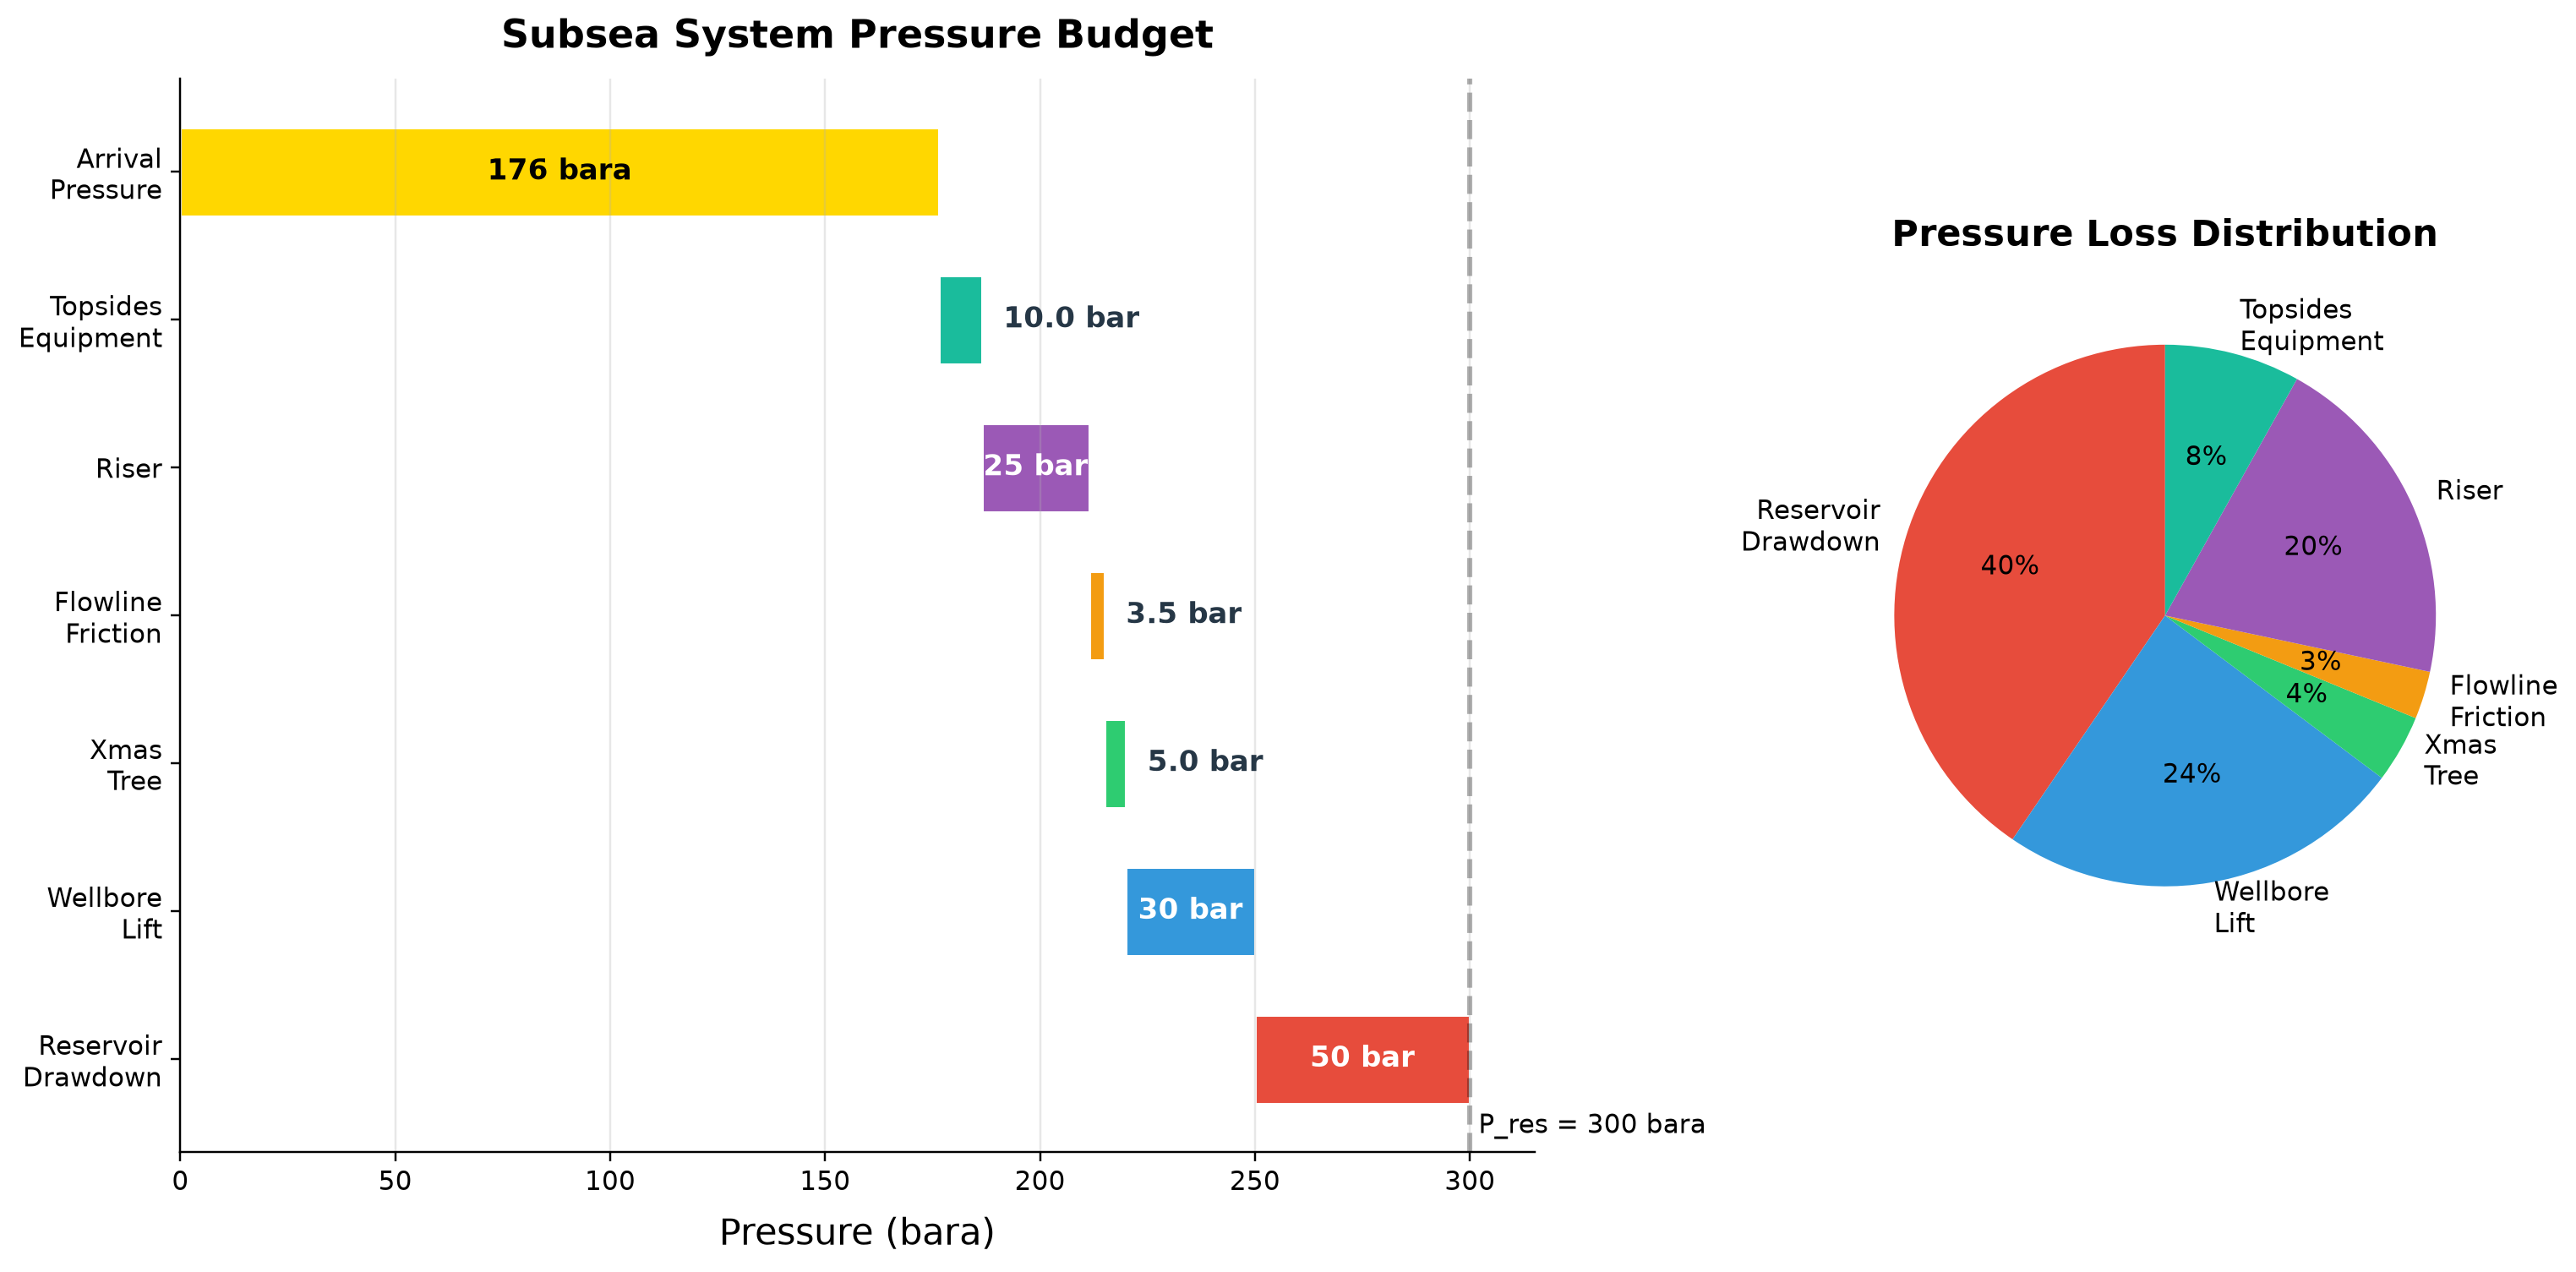

In [9]:
# Pressure budget components (bara)
P_reservoir = 300.0
dP_reservoir_drawdown = 50.0  # IPR drawdown
dP_wellbore = 30.0            # Vertical lift
dP_xmas_tree = 5.0            # Subsea tree
dP_flowline = P_inlet_bara - pressures[-1]  # From our simulation
dP_riser = 25.0               # Riser (vertical lift + friction)
dP_topsides = 10.0            # Topsides choke and equipment
P_separator = P_reservoir - dP_reservoir_drawdown - dP_wellbore - dP_xmas_tree - dP_flowline - dP_riser - dP_topsides

# Stacked bar chart
components = ['Reservoir\nDrawdown', 'Wellbore\nLift', 'Xmas\nTree', 'Flowline\nFriction',
              'Riser', 'Topsides\nEquipment']
values = [dP_reservoir_drawdown, dP_wellbore, dP_xmas_tree, dP_flowline, dP_riser, dP_topsides]
colors_bar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [2, 1]})

# Waterfall chart on the left
cumulative = [P_reservoir]
for v in values:
    cumulative.append(cumulative[-1] - v)

for i, (comp, val, color) in enumerate(zip(components, values, colors_bar)):
    ax1.barh(comp, val, left=cumulative[i+1], color=color, edgecolor='white', height=0.6)
    if val < 15:
        ax1.text(cumulative[i] + 5, i, f'{val:.1f} bar', ha='left', va='center',
                 fontsize=11, fontweight='bold', color='#263746')
    else:
        ax1.text(cumulative[i+1] + val/2, i, f'{val:.0f} bar', ha='center', va='center',
                 fontsize=11, fontweight='bold', color='white')

# Add separator pressure
ax1.barh('Arrival\nPressure', P_separator, left=0, color='gold', edgecolor='white', height=0.6)
ax1.text(P_separator/2, len(components), f'{P_separator:.0f} bara', ha='center', va='center',
         fontsize=11, fontweight='bold')

ax1.set_xlabel('Pressure (bara)', fontsize=14)
ax1.set_title('Subsea System Pressure Budget', fontsize=15)
ax1.axvline(x=P_reservoir, color='black', linestyle='--', alpha=0.3)
ax1.text(P_reservoir + 2, -0.5, f'P_res = {P_reservoir:.0f} bara', fontsize=10)
ax1.grid(True, axis='x', alpha=0.3)

# Pie chart on the right
ax2.pie(values, labels=components, colors=colors_bar, autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 10})
ax2.set_title('Pressure Loss Distribution', fontsize=14)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch06_fig05_pressure_budget.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"\nPressure Budget Summary:")
print(f"  Reservoir pressure:    {P_reservoir:.0f} bara")
for comp, val in zip(components, values):
    print(f"  {comp.replace(chr(10), ' '):25s}: -{val:.0f} bar")
print(f"  {'Arrival pressure':25s}: {P_separator:.0f} bara")
print(f"Figure 5 saved.")


**Executed-figure discussion.** The assumed pressure allocation starts at 300 bara reservoir pressure and ends at 176 bara separation pressure. The individual losses are prescribed budget entries rather than a solved network balance.

The total well-to-platform pressure difference is consumed by tubing lift, choke loss, flowline friction and riser elevation. A negative passive choke loss or a booster with negative power exposes an inconsistent model boundary rather than a production benefit. Check each pressure contribution and the sign of equipment work before allocating additional backpressure or evaluating subsea boosting.


## Summary

This chapter demonstrated key aspects of subsea production system analysis:

1. **Pressure Profile**: NeqSim's Beggs & Brill model accurately predicts pressure drop along the flowline, accounting for multiphase flow effects. The total pressure loss in a 20 km pipeline is a significant portion of the system pressure budget.

2. **Temperature Profile**: Fluid temperature drops significantly as heat is transferred to the cold seawater environment. This cooling is critical for flow assurance — it determines where hydrates, wax, and other solid deposits may form.

3. **Hydrate Risk**: By overlaying the pipeline T-P operating envelope on the hydrate equilibrium curve, we identify whether the system operates within or outside the hydrate formation zone. This guides insulation, inhibitor injection, and depressurization strategies.

4. **Flow Regimes**: The flow regime determines pressure drop correlations, pigging requirements, and slug catcher sizing. Understanding regime transitions is essential for robust pipeline design.

5. **Pressure Budget**: Mapping all pressure losses from reservoir to topsides reveals which components consume the most pressure and where optimization efforts should focus.

### Key Takeaway
Subsea system design requires integrated analysis of fluid thermodynamics, multiphase
flow, and heat transfer. NeqSim provides the thermodynamic and process simulation backbone
for these analyses, enabling engineers to optimize pipeline sizing, insulation, and
chemical injection strategies.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [10]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                            Figure  Panel                        Series                     Output / unit  Minimum   Maximum  Finite points  Missing points
   ch06_fig01_pressure_profile.png      1             Pipeline Pressure                   Pressure (bara)  146.482       150             11               0
ch06_fig02_temperature_profile.png      1             Fluid Temperature                  Temperature (°C)       70        70             11               0
ch06_fig02_temperature_profile.png      1 Seawater Temperature = 4.0 °C                  Temperature (°C)        4         4              2               0
       ch06_fig03_hydrate_risk.png      1     Hydrate Equilibrium Curve                   Pressure (bara)       20       200             15               0
       ch06_fig03_hydrate_risk.png      1 Pipeline Operating Conditions                   Pressure (bara)  146.482       150             11               0
    ch06_fig04_flow_regime_map.png      1                       

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [11]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 499 distinct checks, 685 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Segmented flowline state and pressure budget. Flow-regime map and waterfall allocations are conceptual; hydrate boundary lacks external validation.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
